# test.ipynb — Reproducibility test (required by coursework)

This notebook loads the **saved** MLP and SVM artifacts and evaluates them on the held-out test set **without any retraining**. It is what the markers will run to verify the submitted models.

Preconditions:
- `bash scripts/download_data.sh` has been run so `data/letter-recognition.data` exists.
- `models/mlp_best.pt`, `models/svm_best.joblib`, `models/scaler.joblib`, `models/label_encoder.joblib` are present.

To train from scratch first, run `bash scripts/run_local.sh`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from src.data_loader import prepare
from src.evaluate import load_mlp, mlp_predict
from src.utils import LETTER_CLASSES, mcnemar_test, models_dir, plot_confusion_matrix, set_seed

set_seed(42)

In [2]:
# Reload the dataset and apply the same preprocessing as during training.
data = prepare()
print(f'Test set size: {len(data.y_test)} samples across {len(LETTER_CLASSES)} classes')
print('Device available:', 'cuda' if torch.cuda.is_available() else 'cpu')

Test set size: 4000 samples across 26 classes
Device available: cuda


In [3]:
# --- MLP ---
mlp_model, device = load_mlp()
mlp_pred = mlp_predict(mlp_model, device, data.X_test)
mlp_acc = accuracy_score(data.y_test, mlp_pred)
mlp_f1 = f1_score(data.y_test, mlp_pred, average='macro')
print(f'MLP  — accuracy: {mlp_acc:.4f}   macro-F1: {mlp_f1:.4f}')

MLP  — accuracy: 0.9585   macro-F1: 0.9584


In [4]:
# --- SVM ---
svm = joblib.load(models_dir() / 'svm_best.joblib')
# Saved SVM pipeline contains its own scaler, so pass raw features.
X_test_raw = data.scaler.inverse_transform(data.X_test)
svm_pred = svm.predict(X_test_raw)
svm_acc = accuracy_score(data.y_test, svm_pred)
svm_f1 = f1_score(data.y_test, svm_pred, average='macro')
print(f'SVM  — accuracy: {svm_acc:.4f}   macro-F1: {svm_f1:.4f}')

C:\Users\Endryu\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Endryu\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Endryu\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using

SVM  — accuracy: 0.9735   macro-F1: 0.9736


In [5]:
# Per-class classification reports
print('--- MLP classification report ---')
print(classification_report(data.y_test, mlp_pred, target_names=list(LETTER_CLASSES), zero_division=0))
print('--- SVM classification report ---')
print(classification_report(data.y_test, svm_pred, target_names=list(LETTER_CLASSES), zero_division=0))

--- MLP classification report ---
              precision    recall  f1-score   support

           A       0.97      0.98      0.97       156
           B       0.92      0.96      0.94       136
           C       0.96      0.96      0.96       142
           D       0.91      0.99      0.95       167
           E       0.98      0.93      0.95       152
           F       0.92      0.95      0.94       153
           G       0.97      0.93      0.95       164
           H       0.94      0.87      0.90       151
           I       0.96      0.96      0.96       165
           J       0.97      0.97      0.97       148
           K       0.96      0.95      0.95       146
           L       0.99      0.94      0.96       157
           M       0.95      0.99      0.97       144
           N       0.97      0.92      0.95       166
           O       0.93      0.95      0.94       139
           P       0.98      0.92      0.95       168
           Q       0.96      0.96      0.96    

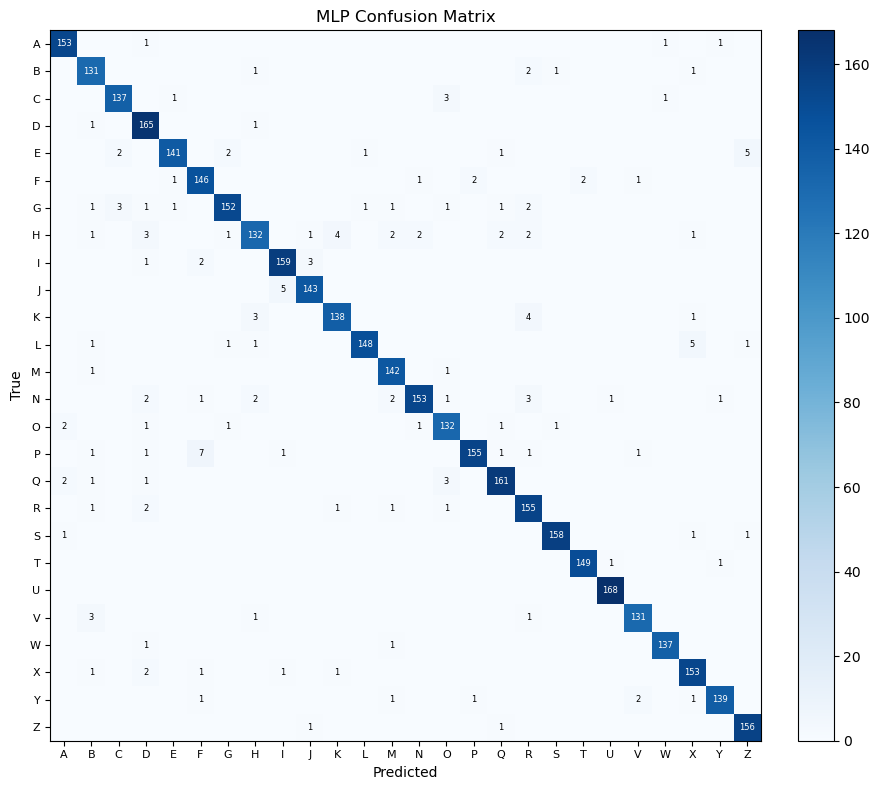

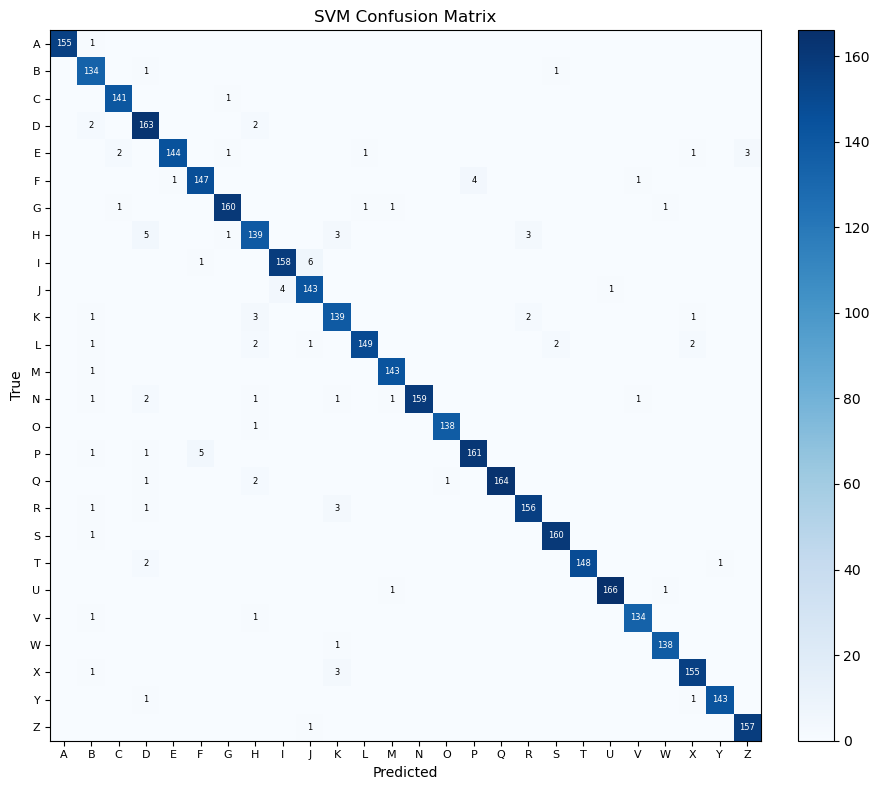

In [6]:
# Confusion matrices
cm_mlp = confusion_matrix(data.y_test, mlp_pred, labels=range(26))
cm_svm = confusion_matrix(data.y_test, svm_pred, labels=range(26))
plot_confusion_matrix(cm_mlp, LETTER_CLASSES, 'MLP Confusion Matrix')
plt.show()
plot_confusion_matrix(cm_svm, LETTER_CLASSES, 'SVM Confusion Matrix')
plt.show()

In [7]:
# McNemar's test — statistical comparison of the two classifiers on the same test set.
stat, p_value, table = mcnemar_test(data.y_test, mlp_pred, svm_pred)
print(f"McNemar's chi^2 = {stat:.4f}   p-value = {p_value:.4g}")
print('Contingency table:')
print('  both correct        :', table[0, 0])
print('  only MLP correct    :', table[0, 1])
print('  only SVM correct    :', table[1, 0])
print('  both wrong          :', table[1, 1])

McNemar's chi^2 = 24.8643   p-value = 6.151e-07
Contingency table:
  both correct        : 3794
  only MLP correct    : 40
  only SVM correct    : 100
  both wrong          : 66


**Expected results** (with the provided seeds and hyperparameters): MLP ~93–96% accuracy, SVM ~96–97% accuracy. McNemar's test typically rejects the null hypothesis that the two classifiers have equal performance at the 5% level.